# (13) tbptt: (T, beta) = (16, 20.0)

project = ```iP-VAE```, host = ```chewie```, device = ```cuda:0```

**Motivation**: <br>

Just establish a model that works, using very tight clamping (annealed using eps), and starting with update_n_exp(1.5) which gives n_exp=10 for the first batch.

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## Trainer

In [3]:
cfg_vae, cfg_tr = default_configs('vH16', 'grad|lin')

cfg_vae['seq_len'] = 16
cfg_vae['tbptt_steps'] = 16
cfg_vae['n_iters_inner'] = 1

cfg_vae['track_stats'] = True

cfg_tr['kl_beta'] = 20.0

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  132.3 K   |
|     ———     |    ———     |
|    layer    |  132.3 K   |
+-------------+------------+

vH16_t-16_z-[512]_<grad|lin>
b200-ep300-lr(0.002)_beta(20:0.1)_temp(0.05:0.5)_gr(200)_(2025_02_14,15:01)

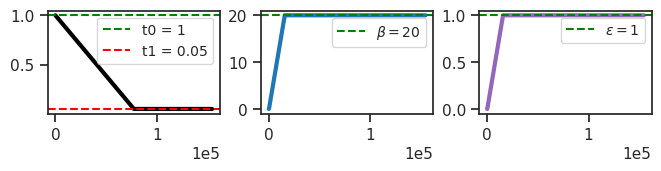

In [4]:
mod = IPVAE(ConfigPoisVAE(**cfg_vae))
tr = Trainer(mod, ConfigTrain(**cfg_tr), device=device)

mod.print()
print(f"{mod.cfg.name()}\n{tr.cfg.name()}_({mod.timestamp})\n")
tr.show_schedules()

In [5]:
print(tr.model.layer.n_exp)

tensor([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10],
       device='cuda:0', dtype=torch.int32)

In [6]:
print(tr.n_iters, tr.cfg.tbptt_accumulate)

154500 True

In [7]:
print(tr.model.layer)

PoissonLayer(input_dim=256, latent_dim=512, temperature=1, beta_inner=1, eps=1)

In [8]:
tr.model.layer.log_bias.shape, tr.model.layer.log_lr.exp()

(torch.Size([1, 512]), tensor([1.], device='cuda:0', grad_fn=<ExpBackward0>))

In [9]:
# cm = f"accumu={tr.cfg.tbptt_accumulate}"
cm = 'annealed-clamp_n-exp-start=10'
tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

# tr.train()

epoch # 300, avg loss: 269.862115: 100%|████| 300/300 [1:46:04<00:00, 21.21s/it]


In [10]:
print(tr.model.layer.n_exp)

tensor([23, 31, 43, 57, 70, 79, 84, 87, 88, 88, 89, 89, 89, 89, 88, 89],
       device='cuda:0', dtype=torch.int32)

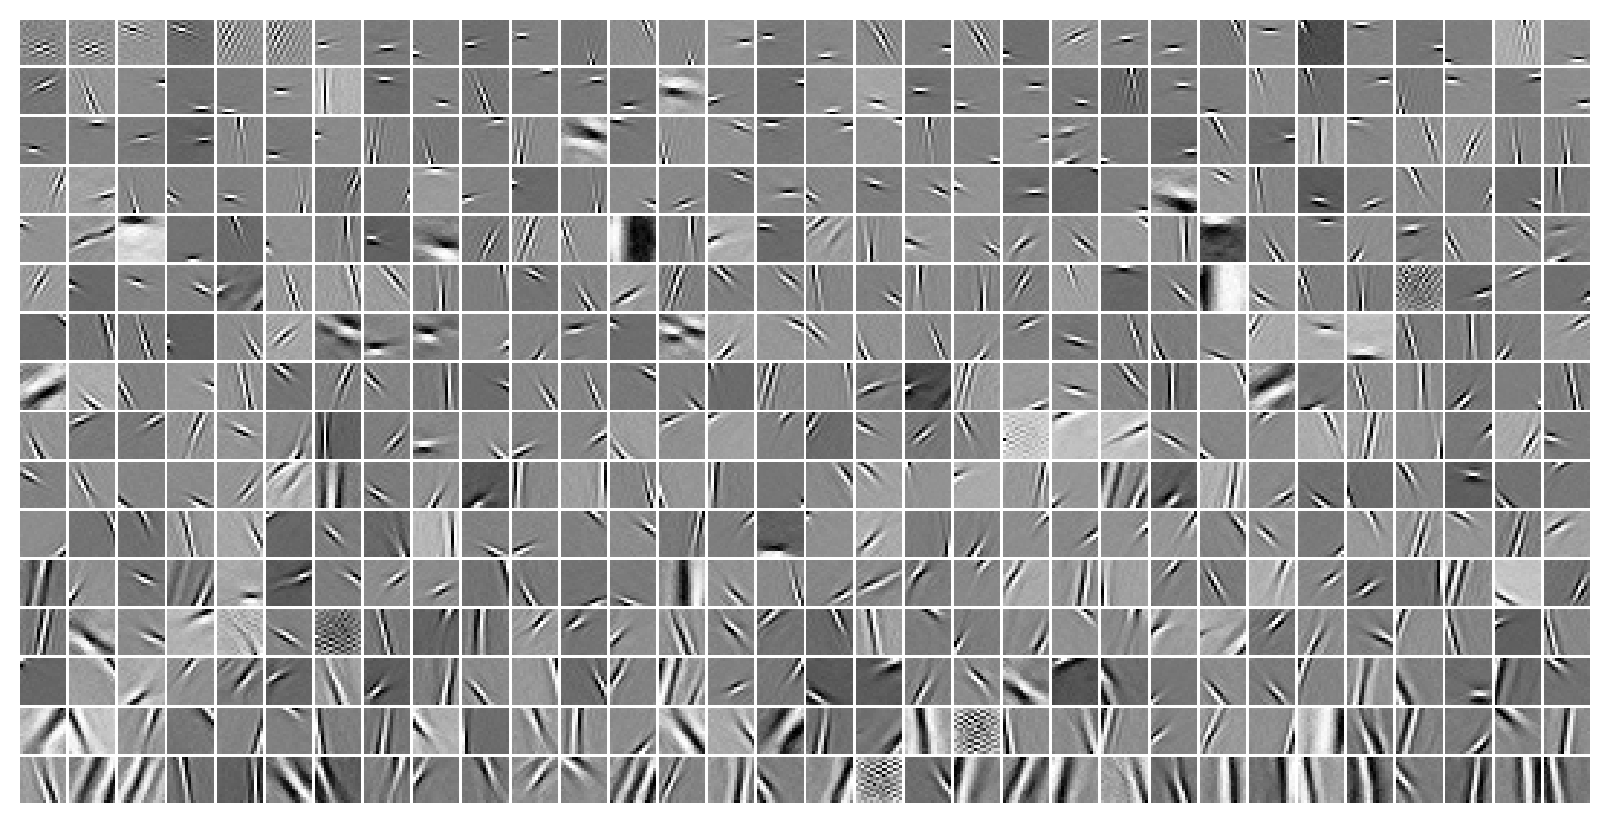

In [11]:
u0 = tonp(tr.model.layer.u_init.squeeze())
tr.model.show(order=np.argsort(u0));

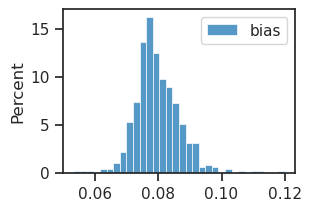

In [12]:
fig, ax = create_figure()

sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

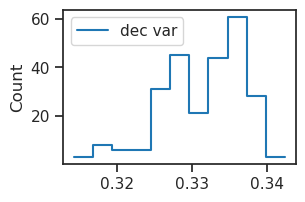

In [13]:
log_scale = tonp(tr.model.layer.log_scale.squeeze())
histplot(np.exp(log_scale) ** 2, label='dec var')
plt.legend()
plt.show()

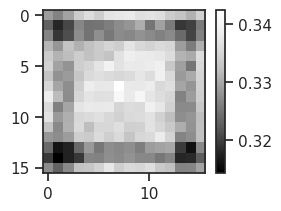

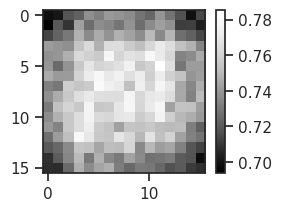

In [14]:
var = np.exp(log_scale) ** 2
var = var.reshape(16, 16)

var_data = tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze()

fig, ax =  create_figure()
imshow(var, cmap='Greys_r')
plt.colorbar()
plt.show()

fig, ax =  create_figure()
imshow(var_data, cmap='Greys_r')
plt.colorbar()
plt.show()

100%|███████████████████████████████████| 2/2 [00:41<00:00, 20.68s/it]


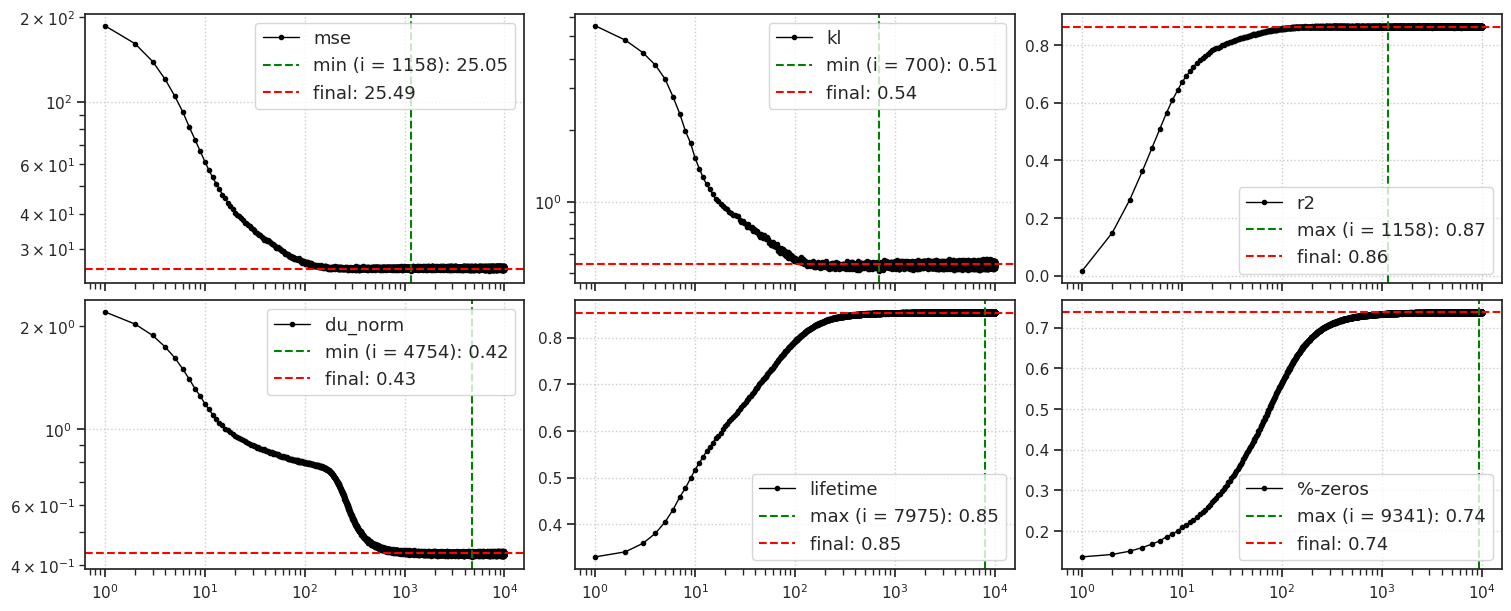

CPU times: user 49.5 s, sys: 3.02 s, total: 52.5 s
Wall time: 52.6 s


In [15]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

## output

In [17]:
output = tr.model.xtract_ftr(
    feeder=tr.get_feeder(),
    seq=range(1000),
    return_extras=True,
).stack()

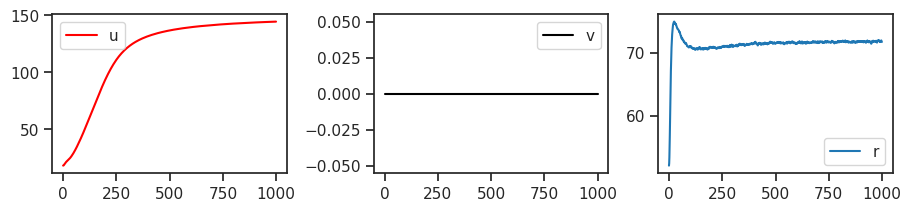

In [18]:
u_norm = tonp(torch.linalg.norm(output['u'], axis=-1).mean(0))
v_norm = tonp(torch.linalg.norm(output['v'], axis=-1).mean(0))
r_norm = tonp(torch.linalg.norm(torch.exp(output['u']), axis=-1).mean(0))

fig, axes = create_figure(1, 3)
axes[0].plot(u_norm, label='u', color='r')
axes[1].plot(v_norm, label='v', color='k')
axes[2].plot(r_norm, label='r')

add_legend(axes)
plt.show()

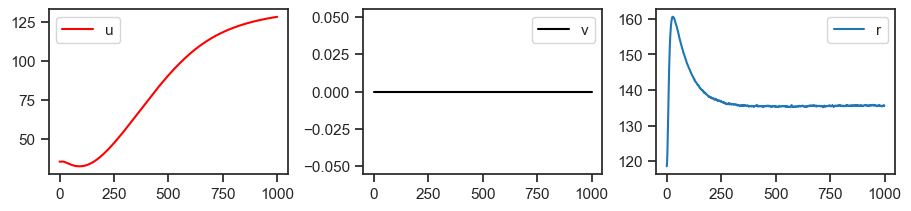

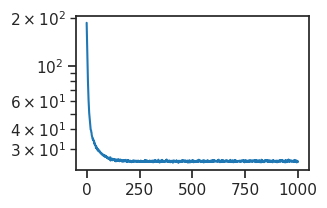

tensor([24.8405, 25.0359, 25.1693, 25.1387, 24.9444], device='cuda:0')

In [19]:
feeder = tr.get_feeder()

locs = torch.stack([
    p.loc for p in
    output['conditional'].values()
], dim=1)
mse = (locs - feeder[0].unsqueeze(1)).pow(2).sum(-1)
plot(mse.mean(0))
plt.yscale('log')
plt.show()

mse.mean(0)[-5:]

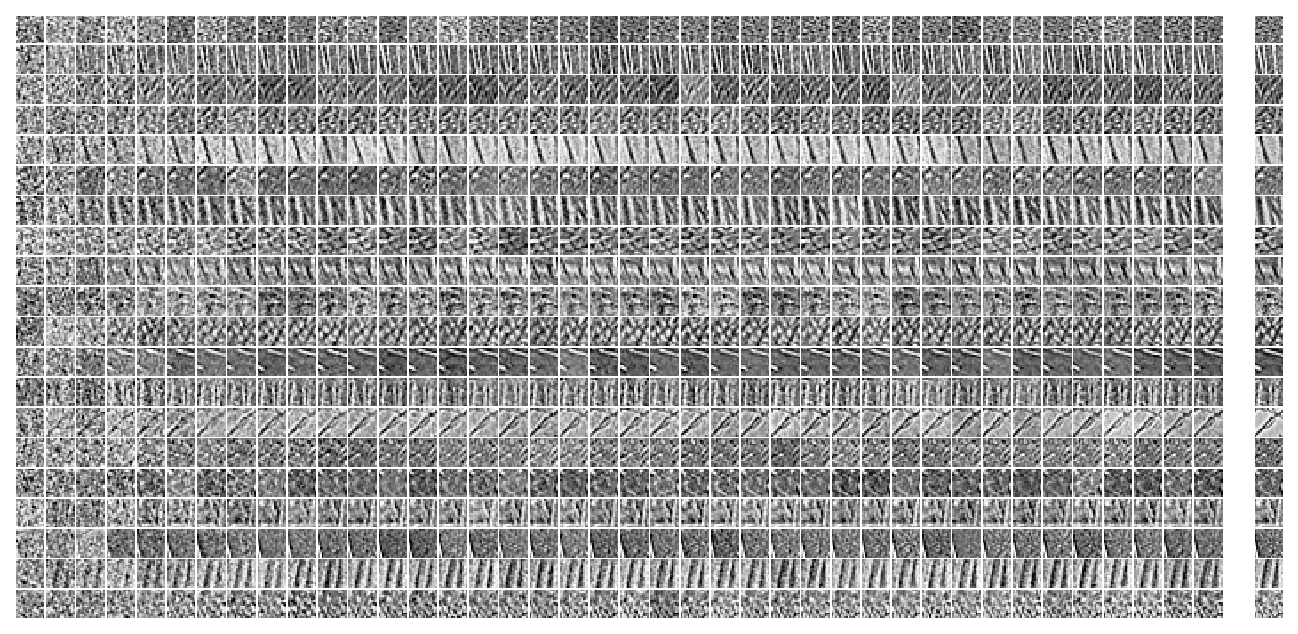

In [20]:
num = 20
n_timepoints = 40

x2p = tonp(locs)[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

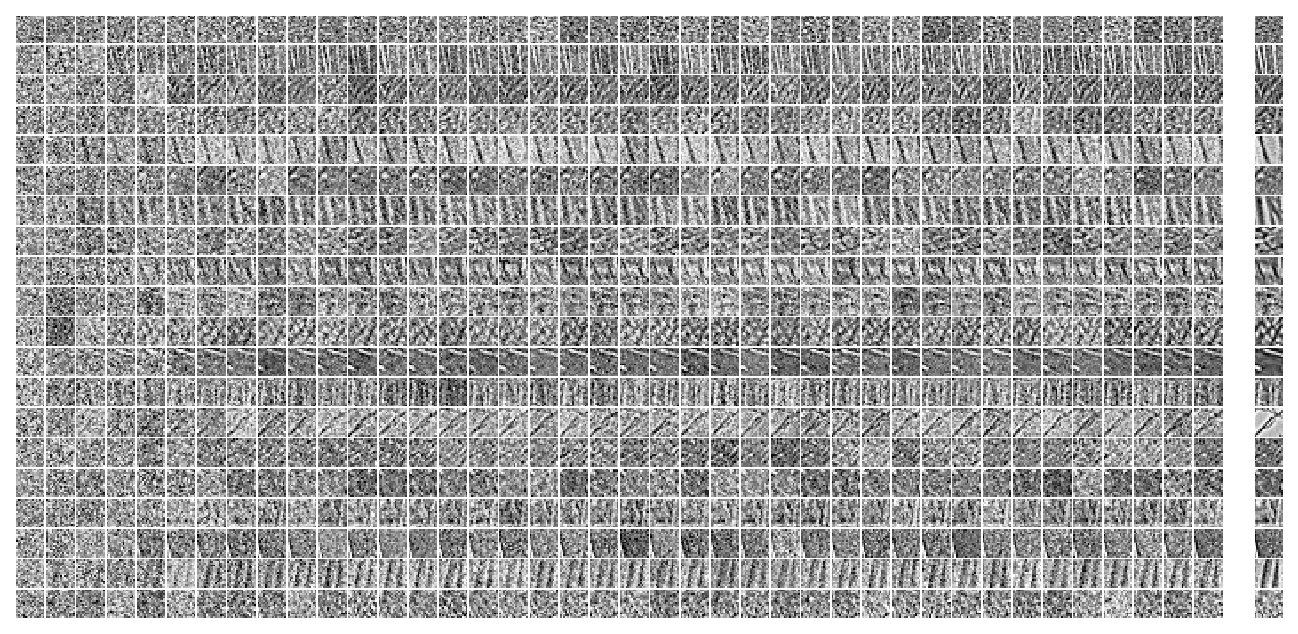

In [21]:
x2p = tonp(output['recon'])[:num]
x2p = x2p[:, :n_timepoints]

true = tonp(feeder[0][:num].unsqueeze(1))
x2p = np.concatenate([x2p, np_nans(true.shape), true], axis=1)

x2p = x2p.reshape(tr.model.cfg.shape)
x2p = x2p.squeeze()

_ = plot_weights(x2p, nrows=num)

In [33]:
tr.time_keys

{'first': '0', 'last': '15', 'avg': 'avg'}

In [34]:
data, loss, etc = tr.forward('vld')
list(loss)

['kl', 'kl_diag', 'recon', 'nelbo']

In [35]:
from main.train import _prep

In [36]:
print(_prep(loss['kl'].mean(0)))

{
    '0': 5.442192,
    '1': 4.7506948,
    '2': 4.2039247,
    '3': 3.7082887,
    '4': 3.2165468,
    '5': 2.7547224,
    '6': 2.3332844,
    '7': 1.9938889,
    '8': 1.7262973,
    '9': 1.5250154,
    '10': 1.3739845,
    '11': 1.2610333,
    '12': 1.1787899,
    '13': 1.1149088,
    '14': 1.0650815,
    '15': 1.0277972,
    'avg': 2.41727814078331
}

In [37]:
print(_prep(loss['recon'].mean(0)))

{
    '0': 373.64783,
    '1': 335.41104,
    '2': 302.84265,
    '3': 275.10626,
    '4': 251.70895,
    '5': 232.36649,
    '6': 216.82545,
    '7': 204.34009,
    '8': 194.5625,
    '9': 186.71965,
    '10': 180.42868,
    '11': 175.3158,
    '12': 171.09148,
    '13': 167.69118,
    '14': 164.84216,
    '15': 162.38939,
    'avg': 224.70559978485107
}

In [38]:
print(_prep(loss['nelbo'].mean(0)))

{
    '0': 379.09097,
    '1': 340.16257,
    '2': 307.04724,
    '3': 278.81497,
    '4': 254.92496,
    '5': 235.12111,
    '6': 219.15784,
    '7': 206.33336,
    '8': 196.28893,
    '9': 188.24492,
    '10': 181.8025,
    '11': 176.57718,
    '12': 172.2711,
    '13': 168.80663,
    '14': 165.90773,
    '15': 163.4169,
    'avg': 227.12305641174316
}